In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
import os

train_path = "../dataset/train"
valid_path = "../dataset/valid"
test_path = "../dataset/test"

train_classes = os.listdir(train_path)
valid_classes = os.listdir(valid_path)
test_classes = os.listdir(test_path)

print("Train Classes:", len(train_classes))
print("Valid Classes:", len(valid_classes))
print("Test Classes:", len(test_classes))

Train Classes: 39
Valid Classes: 38
Test Classes: 2


In [ ]:
def count_images(folder_path):

    total = 0

    for class_name in os.listdir(folder_path):

        class_folder = os.path.join(folder_path, class_name)

        if os.path.isdir(class_folder):

            total += len(os.listdir(class_folder))

    return total


train_count = count_images(train_path)
valid_count = count_images(valid_path)
test_count = count_images(test_path)

print("Training Images:", train_count)
print("Validation Images:", valid_count)
print("Test Images:", test_count)

print("Total Images:",
      train_count + valid_count + test_count)

Training Images: 70295
Validation Images: 17572
Test Images: 33
Total Images: 87900


In [5]:
print(os.listdir(train_path))

['Strawberry___healthy', 'Grape___Black_rot', 'Potato___Early_blight', 'Blueberry___healthy', 'Corn_(maize)___healthy', 'Tomato___Target_Spot', '.DS_Store', 'Peach___healthy', 'Potato___Late_blight', 'Tomato___Late_blight', 'Tomato___Tomato_mosaic_virus', 'Pepper,_bell___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Tomato___Leaf_Mold', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Cherry_(including_sour)___Powdery_mildew', 'Apple___Cedar_apple_rust', 'Tomato___Bacterial_spot', 'Grape___healthy', 'Tomato___Early_blight', 'Corn_(maize)___Common_rust_', 'Grape___Esca_(Black_Measles)', 'Raspberry___healthy', 'Tomato___healthy', 'Cherry_(including_sour)___healthy', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Apple___Apple_scab', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Peach___Bacterial_spot', 'Pepper,_bell___Bacterial_spot', 'Tomato___Septoria_leaf_spot', 'Squash___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot

In [6]:
print("Train Classes:", len(os.listdir(train_path)))
print("Valid Classes:", len(os.listdir(valid_path)))

Train Classes: 38
Valid Classes: 38


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

In [9]:
train_dataset = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)

valid_dataset = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


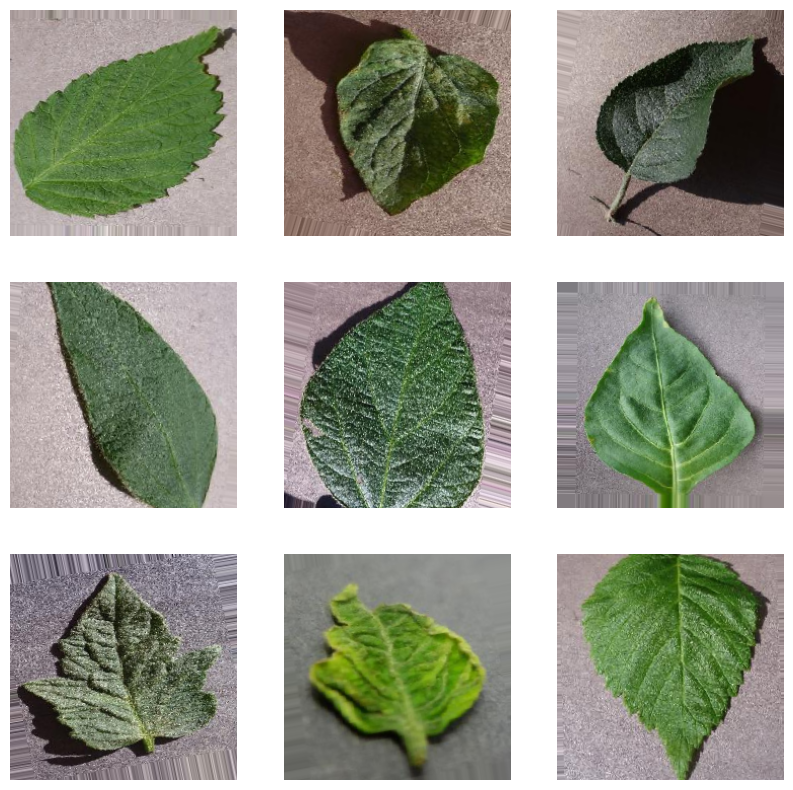

In [10]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset:

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i])

        plt.axis("off")

    break

plt.show()

In [11]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout

In [12]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

2026-05-29 00:52:05.636532: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-05-29 00:52:05.637062: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-29 00:52:05.637068: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-05-29 00:52:05.637110: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-29 00:52:05.637404: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [13]:
base_model.trainable = False

In [14]:
model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dropout(0.3),

    Dense(38, activation="softmax")

])

In [15]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,098,249 (15.63 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [17]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=5
)

Epoch 1/5


2026-05-29 00:54:02.588229: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1414s 639ms/step - accuracy: 0.0268 - loss: 3.6938 - val_accuracy: 0.0276 - val_loss: 3.6879
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2044s 930ms/step - accuracy: 0.0269 - loss: 3.6915 - val_accuracy: 0.0338 - val_loss: 3.6738
Epoch 3/5
  52/2197 ━━━━━━━━━━━━━━━━━━━━ 21:47 610ms/step - accuracy: 0.0240 - loss: 3.6740

KeyboardInterrupt: 

In [18]:
print(train_dataset.class_indices)

{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_blight': 30, 'Tomato

In [19]:
print(valid_dataset.class_indices)

{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_blight': 30, 'Tomato

In [20]:
print(train_path)
print(valid_path)

../dataset/train
../dataset/valid


In [21]:
from tensorflow.keras.applications.efficientnet import preprocess_input

In [22]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [23]:
train_dataset = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)

valid_dataset = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [24]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=5
)

Epoch 1/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1331s 605ms/step - accuracy: 0.8727 - loss: 0.4780 - val_accuracy: 0.9403 - val_loss: 0.2084
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1534s 698ms/step - accuracy: 0.9295 - loss: 0.2337 - val_accuracy: 0.9579 - val_loss: 0.1469
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1218s 554ms/step - accuracy: 0.9411 - loss: 0.1899 - val_accuracy: 0.9621 - val_loss: 0.1279
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 931s 424ms/step - accuracy: 0.9462 - loss: 0.1696 - val_accuracy: 0.9646 - val_loss: 0.1125
Epoch 5/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 993s 452ms/step - accuracy: 0.9489 - loss: 0.1571 - val_accuracy: 0.9647 - val_loss: 0.1091


In [25]:
model.save("../saved_models/plant_disease_transfer_learning.keras")

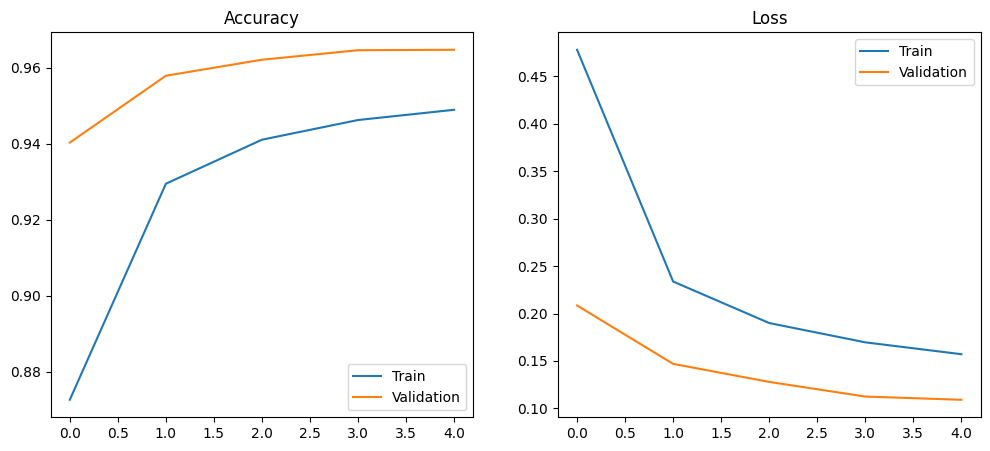

In [26]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train','Validation'])

plt.show()

In [27]:
model.save("../saved_models/plant_disease_transfer_learning.keras")

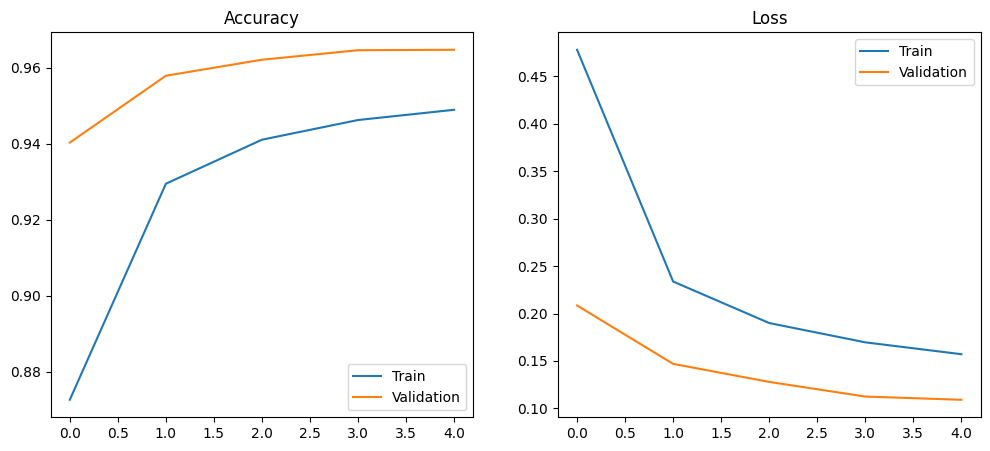

In [28]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train','Validation'])

plt.show()

In [29]:
loss, accuracy = model.evaluate(valid_dataset)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

550/550 ━━━━━━━━━━━━━━━━━━━━ 136s 236ms/step - accuracy: 0.9647 - loss: 0.1089
Validation Loss: 0.1088775098323822
Validation Accuracy: 0.9647166132926941


In [30]:
model.evaluate(valid_dataset)

550/550 ━━━━━━━━━━━━━━━━━━━━ 132s 239ms/step - accuracy: 0.9647 - loss: 0.1091


[0.10905785113573074, 0.9647166132926941]

In [31]:
base_model.trainable = True

In [33]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [34]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [35]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "../saved_models/best_finetuned_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [36]:
fine_tune_history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1414s 636ms/step - accuracy: 0.9052 - loss: 0.3050 - val_accuracy: 0.9612 - val_loss: 0.1198
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1638s 745ms/step - accuracy: 0.9460 - loss: 0.1688 - val_accuracy: 0.9713 - val_loss: 0.0891
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1889s 859ms/step - accuracy: 0.9576 - loss: 0.1315 - val_accuracy: 0.9751 - val_loss: 0.0746
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1638s 745ms/step - accuracy: 0.9642 - loss: 0.1093 - val_accuracy: 0.9790 - val_loss: 0.0636
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1508s 685ms/step - accuracy: 0.9687 - loss: 0.0971 - val_accuracy: 0.9813 - val_loss: 0.0590
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1329s 604ms/step - accuracy: 0.9731 - loss: 0.0830 - val_accuracy: 0.9832 - val_loss: 0.0525
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1679s 763ms/step - accuracy: 0.9751 - loss: 0.0762 - val_accuracy: 0.9848 - val_loss: 0.0491
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1720s 782ms/s

In [37]:
model.save("../saved_models/final_plant_disease_model.keras")